### Step 1: Import Libraries
Load `pandas`/`numpy`, plotting libraries, and `f_oneway` from `scipy.stats` for one-way ANOVA.

In [50]:
import pandas as pd
import numpy as np
import re
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import f_oneway

### Step 2: Load Dataset
Read the smartphone dataset from `Dataset.xlsx`.

In [ ]:
df = pd.read_excel('Dataset.xlsx')

### Step 3: Storage Value Counts
Check how many phones exist for each storage capacity value.

In [52]:
df["Storage"].value_counts()

Storage
128     2580
256     1447
64       927
512      300
32       245
16        62
1024      54
8          9
2048       3
Name: count, dtype: int64

### Step 4: Filter to Standard Storage Sizes
Keep only phones with storage in {64, 128, 256, 512} GB, removing non-standard/invalid values.

In [53]:
allowed_values = [64, 128, 256, 512]
df = df[df["Storage"].isin(allowed_values)]

### Step 5: Verify Filtered Counts
Confirm counts after filtering to standard storage sizes.

In [54]:
df["Storage"].value_counts()

Storage
128    2580
256    1447
64      927
512     300
Name: count, dtype: int64

### Step 6: Re-filter to the Four Storage Groups
Explicitly subset the data to the four storage capacities for the group comparison.

In [55]:
storage_df = df[
    df["Storage"].isin([
        64.0,
        128.0,
        256.0,
        512.0
    ])
].copy()

### Step 7: Verify Group Counts
Confirm the number of phones in each of the four storage groups.

In [56]:
storage_df["Storage"].value_counts()

Storage
128    2580
256    1447
64      927
512     300
Name: count, dtype: int64

### Step 8: Mean Price by Storage
Compute average price for each storage capacity group.

In [57]:
storage_df.groupby("Storage")["Price"].mean()

Storage
64     15762.763754
128    24024.798450
256    46339.768487
512    95002.073333
Name: Price, dtype: float64

### Step 9: Median Price by Storage
Compute median price for each storage capacity group.

In [58]:
storage_df.groupby("Storage")["Price"].median()

Storage
64     10999.0
128    17999.0
256    34999.0
512    92999.0
Name: Price, dtype: float64

### Step 10: Price Standard Deviation by Storage
Measure price variability within each storage group.

In [59]:
storage_df.groupby("Storage")["Price"].std()

Storage
64     15984.866911
128    19344.450136
256    32270.477440
512    44304.118919
Name: Price, dtype: float64

### Step 11: Full Descriptive Statistics
Generate complete descriptive stats for price across the four storage groups.

In [60]:
storage_df.groupby("Storage")["Price"].describe()

,count,mean,std,min,25%,50%,75%,max
Storage,,,,,,,,
64,927.0,15762.763754,15984.866911,5999.0,8531.00,10999.0,14499.0,117100.0
128,2580.0,24024.798450,19344.450136,6264.0,13499.00,17999.0,24999.0,149999.0
256,1447.0,46339.768487,32270.477440,9999.0,24999.00,34999.0,54999.0,177999.0
512,300.0,95002.073333,44304.118919,23894.0,58587.25,92999.0,121999.0,187999.0


### Step 12: Boxplot of Price by Storage
Visualize price distribution across the four storage capacities.

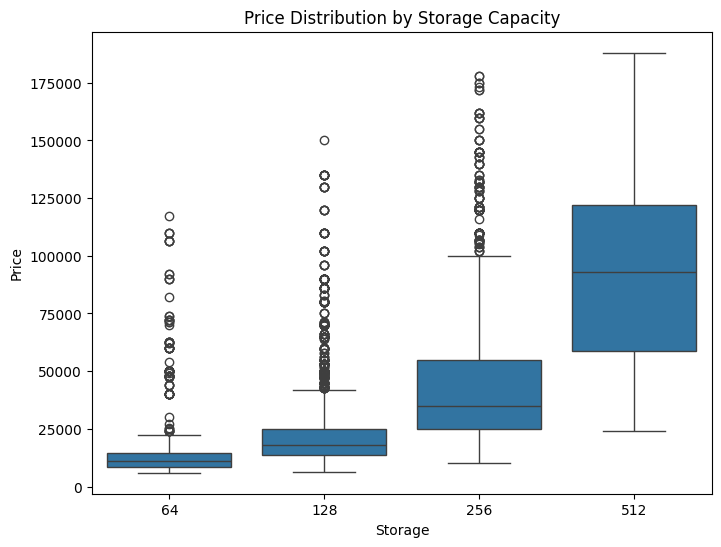

In [62]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=storage_df,
    x="Storage",
    y="Price"
)

plt.title("Price Distribution by Storage Capacity")

plt.show()

### Step 13: One-Way ANOVA
Split prices into four groups (64/128/256/512 GB) and run a one-way ANOVA (`f_oneway`) to test whether mean price differs across storage capacities; print the F-statistic and p-value.

In [64]:
group_64 = storage_df[storage_df["Storage"] == 64.0]["Price"]
group_128 = storage_df[storage_df["Storage"] == 128.0]["Price"]
group_256 = storage_df[storage_df["Storage"] == 256.0]["Price"]
group_512 = storage_df[storage_df["Storage"] == 512.0]["Price"]

f_stat, p_value = f_oneway(
    group_64,
    group_128,
    group_256,
    group_512
)

print("F Statistic:", f_stat)
print("P Value:", p_value)

F Statistic: 1005.957683690017
P Value: 0.0


### Step 14: Tukey HSD Post-Hoc Test
Since ANOVA only tells us *some* group differs, run Tukey's HSD test to identify exactly **which** pairs of storage groups have statistically significant price differences.

In [66]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd(
    endog=storage_df["Price"],
    groups=storage_df["Storage"],
    alpha=0.05
)

print(tukey)

    Multiple Comparison of Means - Tukey HSD, FWER=0.05    
group1 group2  meandiff  p-adj   lower      upper    reject
-----------------------------------------------------------
    64    128  8262.0347   0.0  5796.9218 10727.1476   True
    64    256 30577.0047   0.0 27868.7789 33285.2306   True
    64    512 79239.3096   0.0 74963.2825 83515.3367   True
   128    256   22314.97   0.0 20200.6761 24429.2639   True
   128    512 70977.2749   0.0 67050.4239 74904.1259   True
   256    512 48662.3048   0.0 44578.4507  52746.159   True
-----------------------------------------------------------
